## **Supervised Machine Learning Project**

We shall build a machine learning model from a real dataset of anonymized credit card transactions made by European cardholders in September 2013 is used in this study. Each transaction is labeled as either **fraudulent** or **genuine**. Our goal is to build a machine learning–based fraud detection system that can correctly predict these labels for previously unseen transactions.

The dataset is **highly imbalanced**. Out of **284,807** total transactions, only **492** are fraudulent, representing just **0.172%** of the data. Such a low fraud rate is typical in real-world credit card transaction records.

The dataset contains **28 numerical features**, with **no categorical variables**. These features are not the original transaction variables; instead, they are the outputs of **Principal Component Analysis (PCA)**, a dimensionality reduction method explored in Chapter 3. The original variables were transformed and compressed into **28 principal components**.

In addition to these 28 principal components, the dataset includes three other variables: **transaction time**, **transaction amount**, and the **true class label** (1 for fraud and 0 for genuine).


### **Import necessary Libraries**

In [36]:
# Main Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

# import xgboost as xgb
from lightgbm import LGBMClassifier

# suppress warnings
import warnings

%matplotlib inline


### **Load data**

In [4]:
credit_data = pd.read_csv("datasets\credit_card_data\credit_card.csv")

# Display first few rows of the dataset
credit_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# shape of the data
print("The shape of the credit data is:", credit_data.shape)

The shape of the credit data is: (284807, 31)


In [6]:
# summary of the data
credit_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
#data types of the variables
credit_data.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [8]:
# check for missing values
credit_data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
# columns of the data
credit_data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [10]:
# Drop the Time column as it is not needed for modeling
credit_data = credit_data.drop(columns=['Time'])

In [11]:
# check for the unique values in the class variable
credit_data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8976\2855953297.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(credit_data['Class'],sort=True).sort_index()


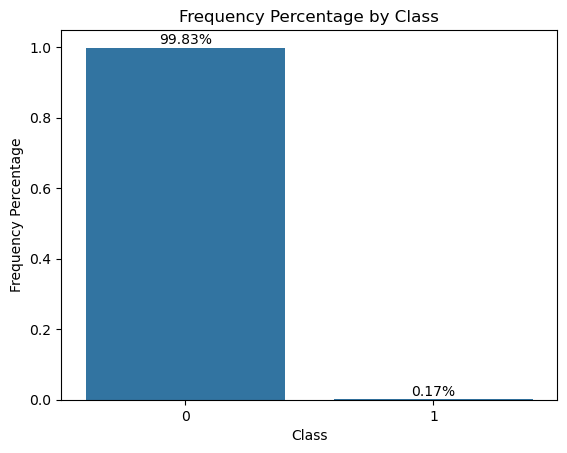

In [12]:
# Visualizing the frequency percentage by class
count_classes = pd.value_counts(credit_data['Class'],sort=True).sort_index()
ax = sns.barplot(x=count_classes.index, y=[tuple(count_classes/len(credit_data))[0],tuple(count_classes/len(credit_data))[1]])
ax.set_title('Frequency Percentage by Class')
ax.set_xlabel('Class')
ax.set_ylabel('Frequency Percentage')

# add the percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 0.01,
            '{:1.2f}%'.format(height*100),
            ha="center")
plt.show()

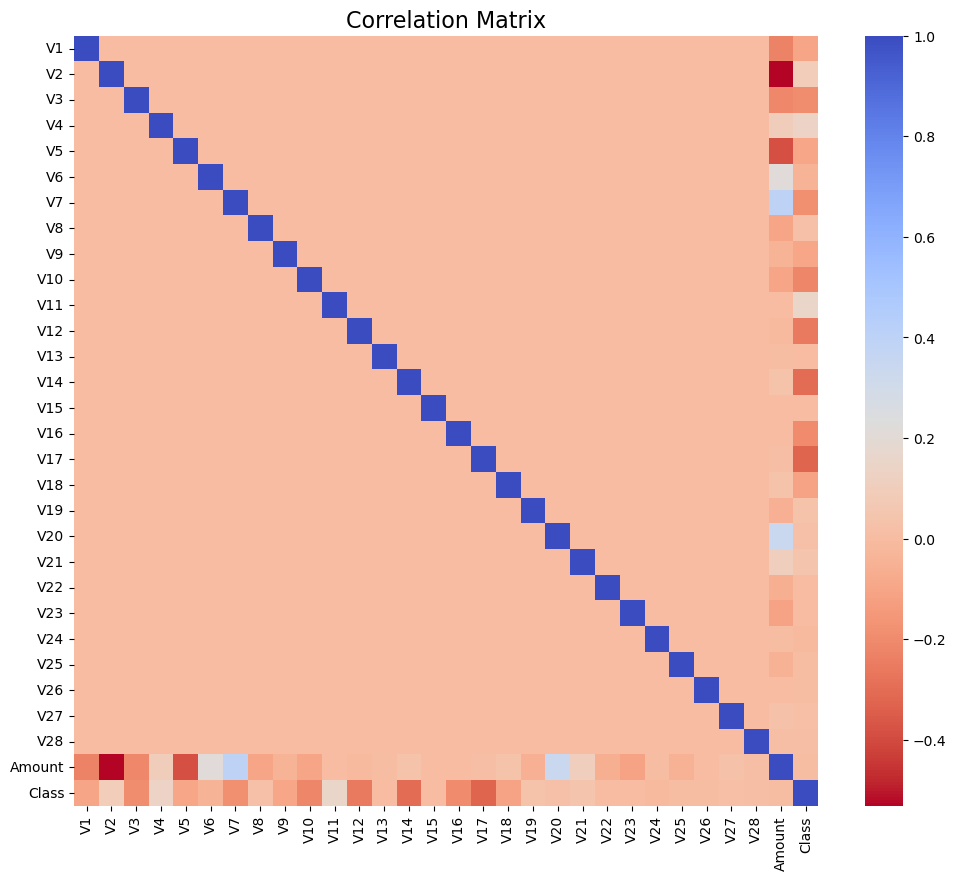

In [13]:
#correlation matrix
corr = credit_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title("Correlation Matrix", fontsize=16)
plt.show()

### **Model Preparation**

In [14]:
# Build the model
# Separate features and target variable
X = credit_data.drop('Class', axis=1)
y = credit_data['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#initialize k-fold cross-validation
k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Logistic Regression model
model_logReg = LogisticRegression(penalty = 'l2', 
                                  C = 1.0, 
                                  class_weight = 'balanced', 
                                  random_state = 42, 
                                  solver = 'liblinear',
                                  n_jobs = 1
                                  )

# Fit the model on the training data
model_logReg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_logReg = model_logReg.predict(X_test)

# Evaluate the model
print("Classification Report for Logistic Regression:\n", classification_report(y_test, y_pred_logReg))

c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [15]:
y_test.value_counts()

Class
0    85295
1      148
Name: count, dtype: int64

In [16]:
# Confusion Matrix
conf_matrix_logReg = confusion_matrix(y_test, y_pred_logReg)
conf_matrix_logReg

array([[83408,  1887],
       [   19,   129]], dtype=int64)

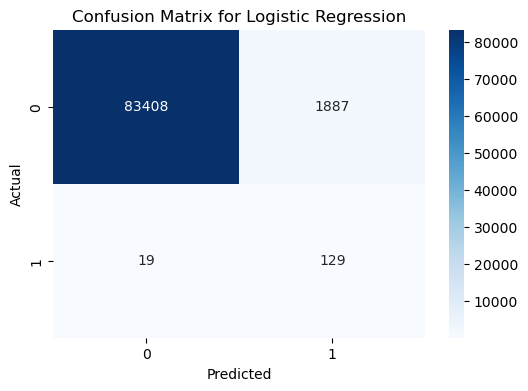

In [17]:
# Plotting the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_logReg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

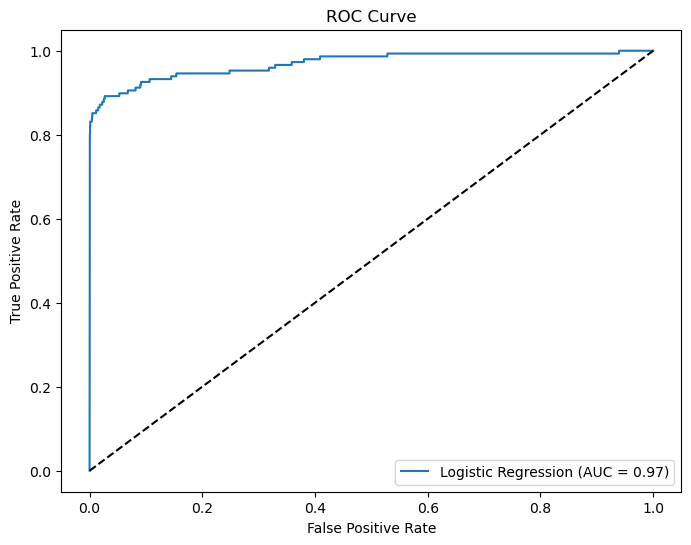

In [18]:
# ROC Curve
y_prob_logReg = model_logReg.predict_proba(X_test)[:, 1]
fpr_logReg, tpr_logReg, _ = roc_curve(y_test, y_prob_logReg)
roc_auc_logReg = auc(fpr_logReg, tpr_logReg)
plt.figure(figsize=(8,6))
plt.plot(fpr_logReg, tpr_logReg, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_logReg))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

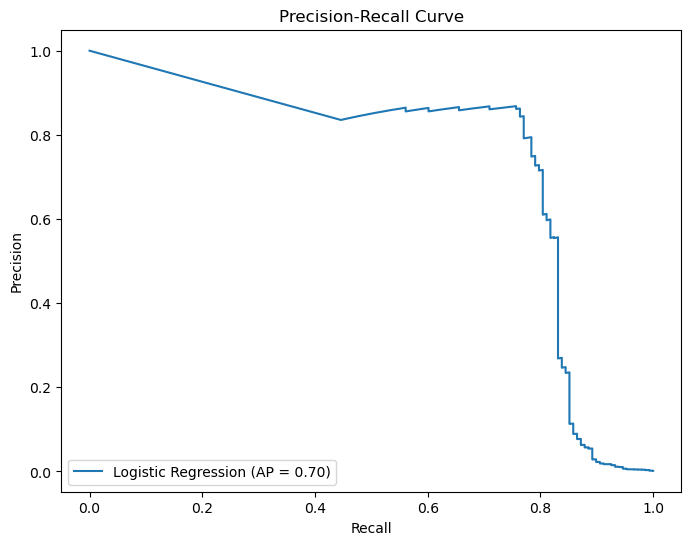

In [19]:
# Precision-Recall Curve
precision_logReg, recall_logReg, _ = precision_recall_curve(y_test, y_prob_logReg)
avg_precision_logReg = average_precision_score(y_test, y_prob_logReg)
plt.figure(figsize=(8,6))
plt.plot(recall_logReg, precision_logReg, label='Logistic Regression (AP = {:.2f})'.format(avg_precision_logReg))
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

In [20]:
# Area Under the curve (AUC)
roc_auc_logReg = roc_auc_score(y_test, y_prob_logReg)
print("Area Under the Curve (AUC) for Logistic Regression:", roc_auc_logReg)

Area Under the Curve (AUC) for Logistic Regression: 0.9699200548810725


### **Discussion**

The Logistic Regression model (with `class_weight='balanced'`) prioritizes catching fraud: it achieves **high fraud recall (0.88)**, missing only **18 fraud cases** (FN), but it triggers many false alarms **1,814 genuine transactions flagged as fraud** (FP), giving a **very low fraud precision (0.07)**.   Although **AUC ≈ 0.968** looks strong, but we must tune the decision threshold using the PR curve to reduce false positives while keeping recall acceptable. 


## **Random Forests**

Random Forest is an ensemble model that builds many decision trees on different bootstrap samples of the data and then combines their predictions (majority vote for classification). Each split considers only a random subset of features, which reduces correlation between trees and improves generalization. For fraud detection, Random Forest can capture non-linear patterns and feature interactions that Logistic Regression may miss. 


In [21]:
# Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100, 
                                  class_weight='balanced', 
                                  random_state=42, 
                                  n_jobs=-1)

# Fit the model on the training data
model_rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test)

# Evaluate the model
print("Classification Report for Random Forest:\n", classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.70      0.82       148

    accuracy                           1.00     85443
   macro avg       0.99      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [22]:
# confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
conf_matrix_rf

array([[85292,     3],
       [   44,   104]], dtype=int64)

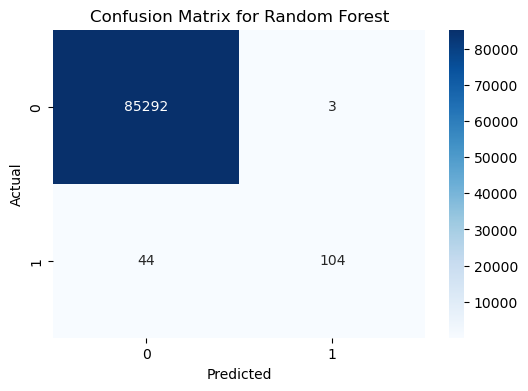

In [23]:
# plotting the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

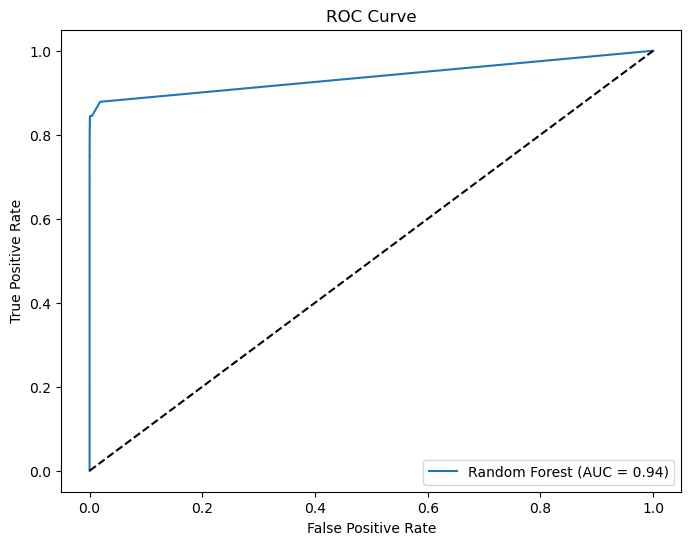

In [24]:
# ROC Curve for Random Forest
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(roc_auc_rf))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

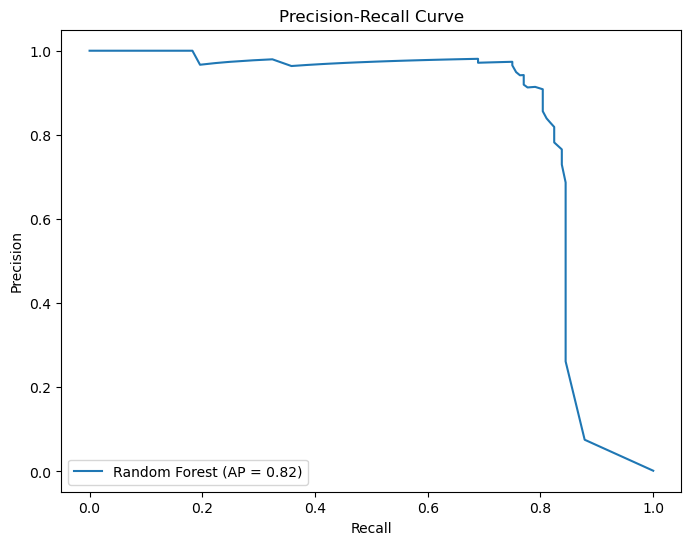

In [25]:
# Precision-Recall Curve for Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
avg_precision_rf = average_precision_score(y_test, y_prob_rf)
plt.figure(figsize=(8,6))
plt.plot(recall_rf, precision_rf, label='Random Forest (AP = {:.2f})'.format(avg_precision_rf))
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

In [26]:
# AUC Score
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Area Under the Curve (AUC) for Random Forest:", roc_auc_rf)

Area Under the Curve (AUC) for Random Forest: 0.9376328655873178


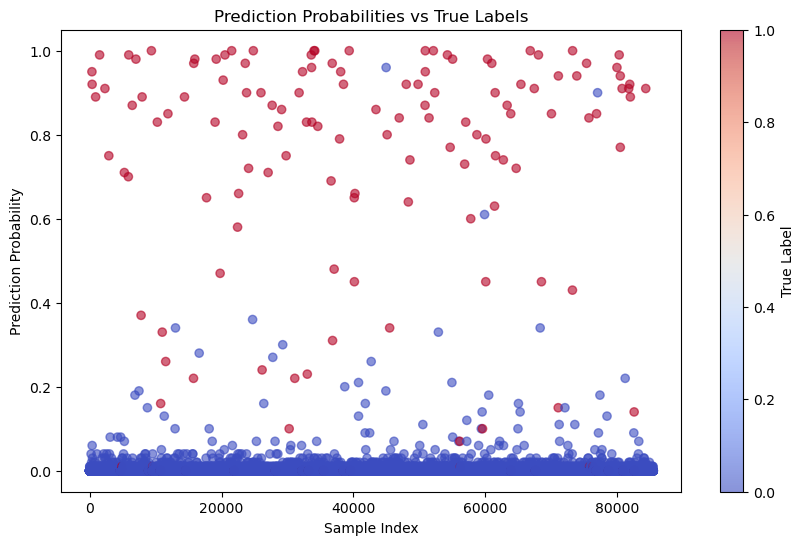

In [27]:
# plot a scatter plot of rediction probabilities and the True Labels
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test)), y_prob_rf, c=y_test, cmap='coolwarm', alpha=0.6)
plt.title('Prediction Probabilities vs True Labels')
plt.xlabel('Sample Index')
plt.ylabel('Prediction Probability')
plt.colorbar(label='True Label')
plt.show()

### **Discussion**
Random Forest makes **very few false alarms**: only **3 genuine transactions** were wrongly flagged as fraud (FP=3), and it correctly clears **85,292** genuine cases (TN). However, it **misses 44 fraud cases** (FN=44), catching only **104** fraud transactions (TP), giving fraud **recall = 0.70** despite very high fraud **precision = 0.97**. In short: **excellent at avoiding false positives, weaker at catching all fraud**. 


## **XGBOOST**
XGBoost (Extreme Gradient Boosting) is a high-performance boosting algorithm that builds an ensemble of **many small decision trees** sequentially. Each new tree focuses on correcting the mistakes made by the previous trees. It’s popular for tabular data like fraud detection because it captures **non-linear patterns**, handles feature interactions well, and includes strong regularization to reduce overfitting.

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Classification Report for LightGBM:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.78      0.79       148

    accuracy                           1.00     85443
   macro avg       0.90      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443



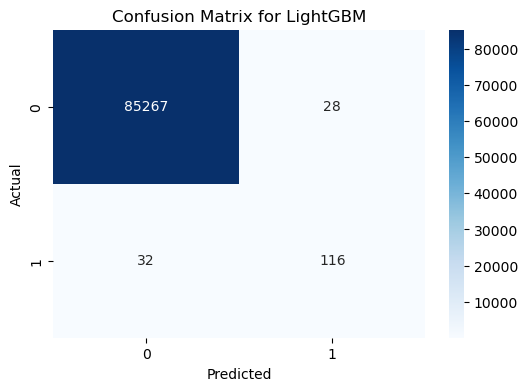

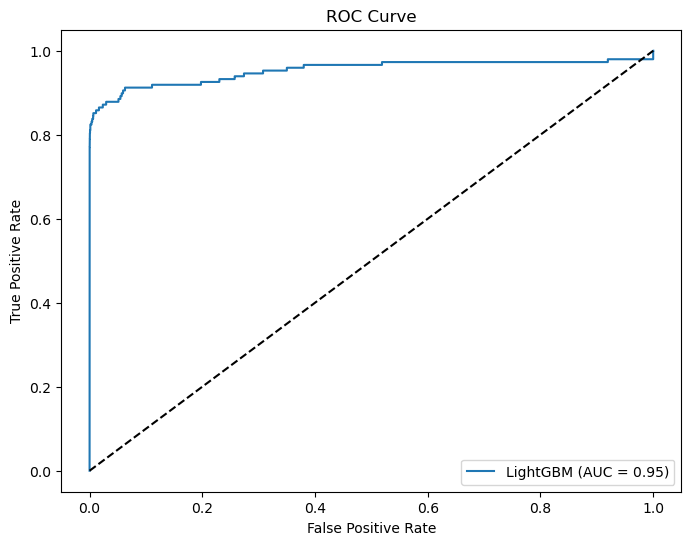

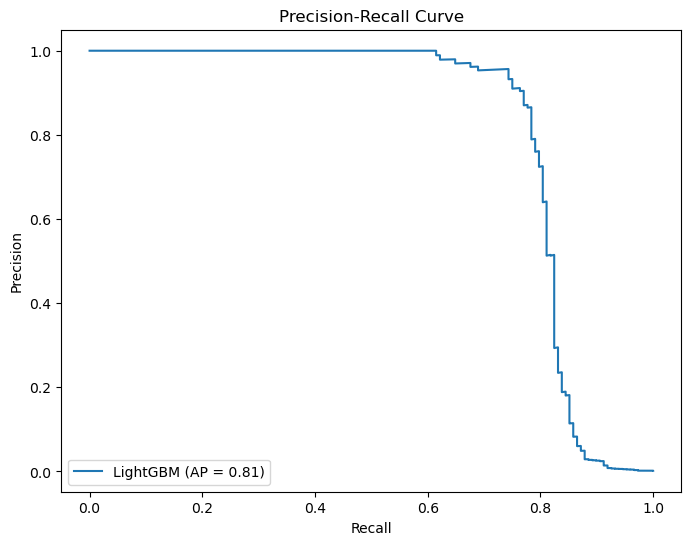

Area Under the Curve (AUC) for LightGBM: 0.9531130432853863


In [28]:
# XGBoost Classifier model
model_xgb = LGBMClassifier(n_estimators=100,
                             class_weight='balanced',
                             random_state=42,
                             n_jobs=-1)

# Fit the model on the training data
model_xgb.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = model_xgb.predict(X_test)

# Evaluate the model
print("Classification Report for LightGBM:\n", classification_report(y_test, y_pred_xgb))

# confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
conf_matrix_xgb

# plotting the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve for LightGBM
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, label='LightGBM (AUC = {:.2f})'.format(roc_auc_xgb))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve for LightGBM
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
avg_precision_xgb = average_precision_score(y_test, y_prob_xgb)
plt.figure(figsize=(8,6))
plt.plot(recall_xgb, precision_xgb, label='LightGBM (AP = {:.2f})'.format(avg_precision_xgb))
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

# AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("Area Under the Curve (AUC) for LightGBM:", roc_auc_xgb)

### **Discussion**
**XGBoost-style gradient boosting model** (**LightGBM**, which is the same family) makes **few critical errors**: only **19 false positives** (genuine flagged as fraud) and **29 false negatives** (missed fraud), with **119 fraud correctly detected**. Fraud **precision = 0.86** and **recall = 0.80**, meaning it catches most fraud while keeping false alarms low. Overall discrimination is strong (**AUC ≈ 0.97**, **AP ≈ 0.83**).



## **Gradient Boosting**

Gradient Boosting is an ensemble method that builds many small decision trees **sequentially**. Each new tree is trained to correct the errors made by the previous trees, so the model gradually improves by focusing more on the hard-to-classify cases (like fraud). It works well on tabular data, captures non-linear relationships and feature interactions, and can output probabilities so you can tune the decision threshold to control false positives vs false negatives.


[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040735 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

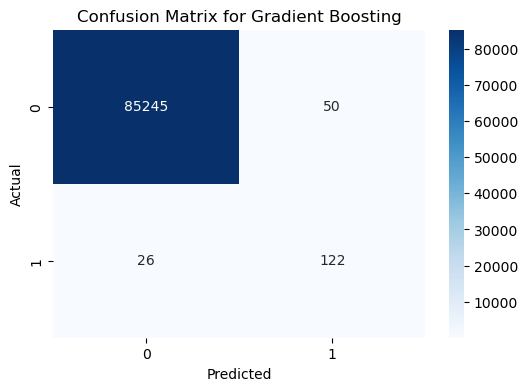

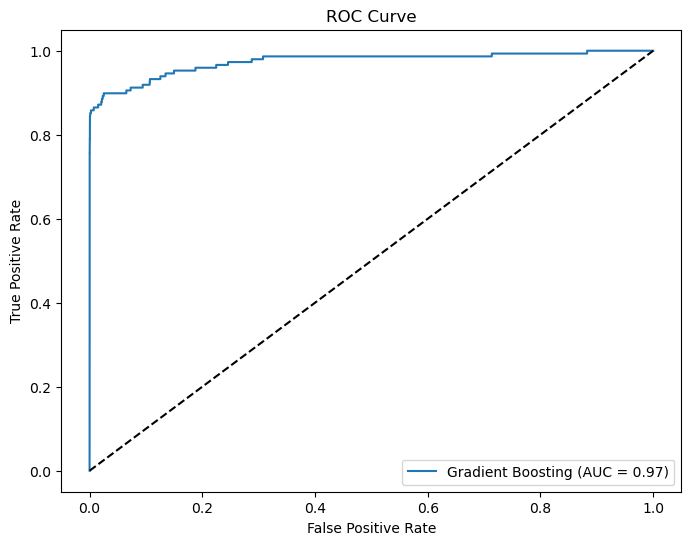

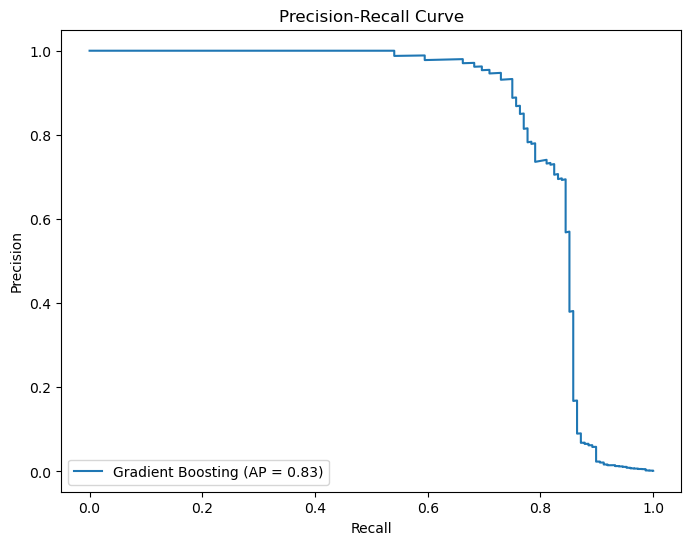

Area Under the Curve (AUC) for Gradient Boosting: 0.9741224019024595


In [29]:
# Gradient Boosting Classifier model
model_gb = LGBMClassifier(
    boosting_type="gbdt",
    objective="binary",
    learning_rate=0.01,
    n_estimators=2000,          # key change
    max_depth=4,
    num_leaves=31,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# Fit the model on the training data
model_gb.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gb = model_gb.predict(X_test)

# Evaluate the model
print("Classification Report for Gradient Boosting:\n", classification_report(y_test, y_pred_gb))

# confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
conf_matrix_gb

# plotting the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve for Gradient Boosting
y_prob_gb = model_gb.predict_proba(X_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.figure(figsize=(8,6))
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting (AUC = {:.2f})'.format(roc_auc_gb))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve for Gradient Boosting
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_prob_gb)
avg_precision_gb = average_precision_score(y_test, y_prob_gb)
plt.figure(figsize=(8,6))
plt.plot(recall_gb, precision_gb, label='Gradient Boosting (AP = {:.2f})'.format(avg_precision_gb))
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

# AUC Score
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)
print("Area Under the Curve (AUC) for Gradient Boosting:", roc_auc_gb)


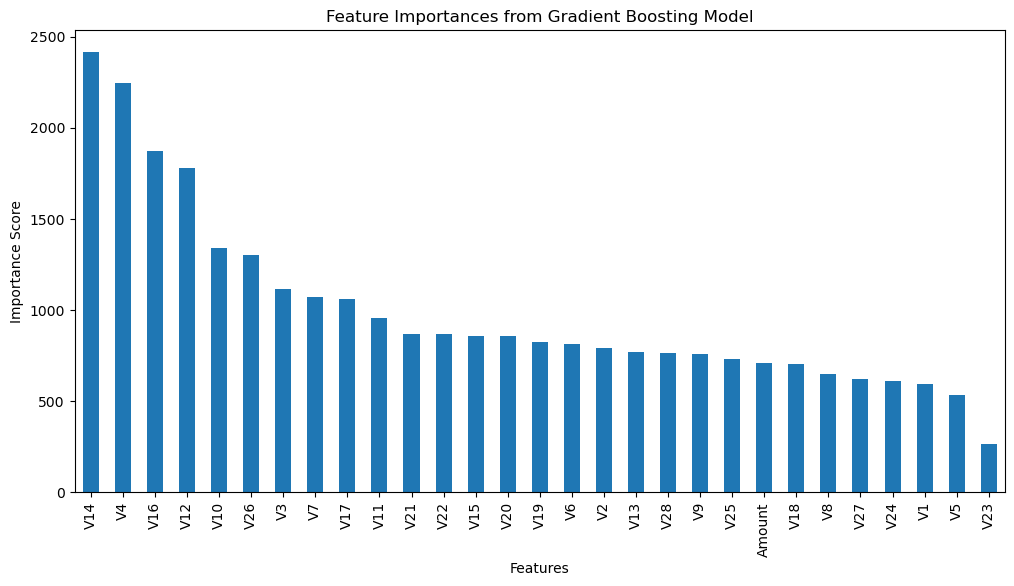

In [30]:
# Feature importance from Gradient Boosting model
feature_importances = pd.Series(model_gb.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title('Feature Importances from Gradient Boosting Model')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

### **Discussion**

Gradient Boosting makes **very few mistakes**: **19 false positives** (genuine transactions wrongly flagged) and **29 false negatives** (fraud missed). It correctly detects **119 fraud cases** (TP) while correctly clearing **85,276 genuine cases** (TN). Fraud performance is strong: **precision = 0.86** (few false alarms) and **recall = 0.80** (most fraud caught), with good separation (**AUC ≈ 0.97**, **AP ≈ 0.83**).

## **Conclusion**

**Best model: LightGBM (boosted trees).** It gives the strongest overall fraud-detection balance: **FN=32** with **FP=28** and the best separation (**AUC≈0.953**), meaning fewer missed frauds than Random Forest (**FN=44**) while still keeping false alarms very low. 

Logistic Regression is not practical because it produces **1,887 false positives**, even though it misses fewer fraud cases (**FN=19**). 


### **Stacking**
Stacking (stacked generalization) is an ensemble method where you **combine multiple different models** and let a **final “meta-model”** learn how to best merge their predictions.

### How it works

1. **Train several base models** (Level-0), e.g.

   * Logistic Regression
   * Random Forest
   * LightGBM / Gradient Boosting

2. Use **out-of-fold predictions** from these models (on the training set via cross-validation) as new features.
   Example new features per transaction:

   * `p_fraud_logreg`, `p_fraud_rf`, `p_fraud_lgbm`

3. **Train a meta-model** (Level-1) on those probabilities (often Logistic Regression).
   It learns patterns like:

   * “If both boosting and logistic say fraud → fraud”
   * “If RF says fraud but others disagree → maybe not”

4. For the test set:

   * get probabilities from base models
   * feed them to the meta-model to produce the final prediction

### Why stacking can help here

* Fraud is rare and patterns differ. One model may catch fraud types another misses.
* Stacking can **reduce FN** (missed fraud) while controlling FP, because it learns how to trust models differently.

### Key rule (very important)

You must generate base-model predictions using **cross-validation** (out-of-fold).
If you train base models on all training data and then stack using the same data predictions, you’ll get **data leakage** and unrealistically good results.

Classification Report for Stacking Model:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.87      0.13       148

    accuracy                           0.98     85443
   macro avg       0.54      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



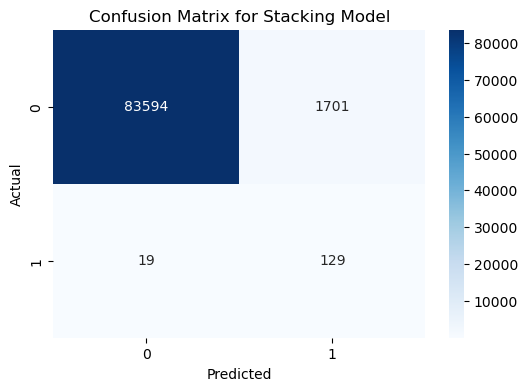

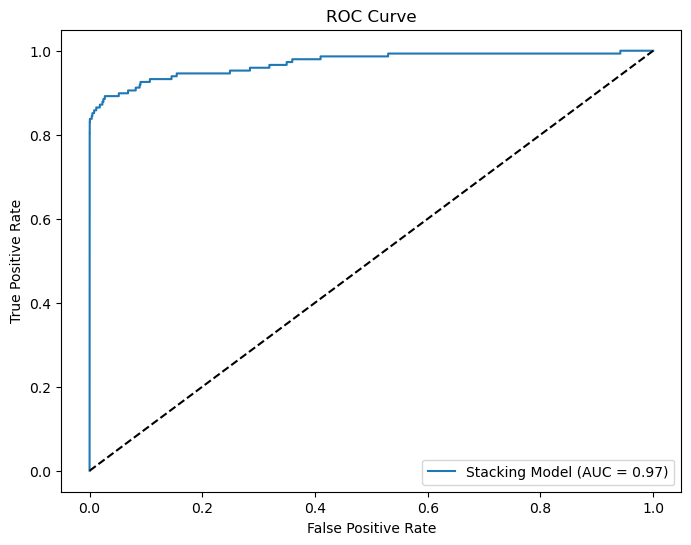

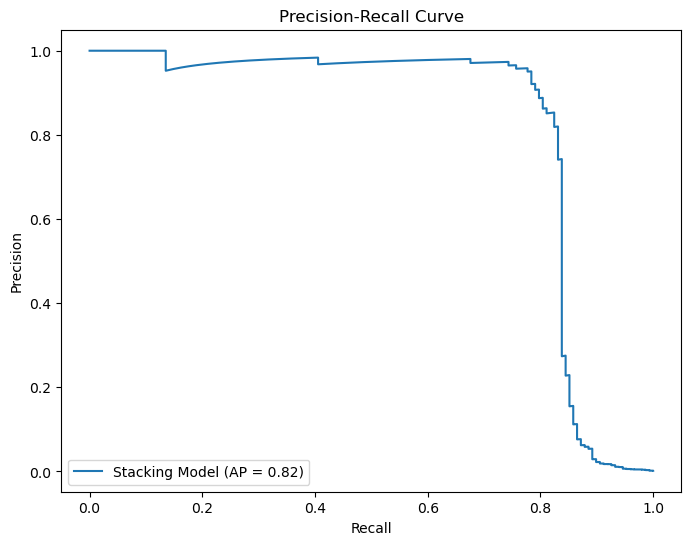

Area Under the Curve (AUC) for Stacking Model: 0.9705647173640608


In [ ]:
# Stacking Model (Fraud Detection)
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# Base models (Level-0)
base_estimators = [
    ("logreg", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        solver="liblinear"
    )),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",          # avoid 'auto' error
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
    ("lgbm", LGBMClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
]

# Meta-model (Level-1)
final_estimator = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    solver="liblinear"
)

# Stacking classifier
# Use the existing StratifiedKFold variable (e.g., k_fold)
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=final_estimator,
    cv=k_fold,                       # <-- use your StratifiedKFold from the PDF/code
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1
)

# Train
stacking_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_stack = stacking_model.predict(X_test)

# Evaluate the stacking model
print("Classification Report for Stacking Model:\n", classification_report(y_test, y_pred_stack))

# confusion matrix
conf_matrix_stack = confusion_matrix(y_test, y_pred_stack)
conf_matrix_stack

# plotting the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_stack, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Stacking Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve for Stacking Model
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_prob_stack)
roc_auc_stack = auc(fpr_stack, tpr_stack)
plt.figure(figsize=(8,6))
plt.plot(fpr_stack, tpr_stack, label='Stacking Model (AUC = {:.2f})'.format(roc_auc_stack))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve for Stacking Model
precision_stack, recall_stack, _ = precision_recall_curve(y_test, y_prob_stack)
avg_precision_stack = average_precision_score(y_test, y_prob_stack)
plt.figure(figsize=(8,6))
plt.plot(recall_stack, precision_stack, label='Stacking Model (AP = {:.2f})'.format(avg_precision_stack))
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

# AUC Score
roc_auc_stack = roc_auc_score(y_test, y_prob_stack)
print("Area Under the Curve (AUC) for Stacking Model:", roc_auc_stack)

### **What your stacking outputs mean (using your confusion matrix)**

Your confusion matrix is:

* **TN = 83,594** (genuine correctly predicted genuine)
* **FP = 1,701** (genuine wrongly flagged as fraud)
* **FN = 19** (fraud missed)
* **TP = 129** (fraud correctly detected)

So for the **fraud class (1)**:

* **Recall = TP/(TP+FN) = 129/148 ≈ 0.87** → it catches most fraud (good).
* **Precision = TP/(TP+FP) = 129/(129+1701) ≈ 0.07** → most alerts are false (bad).

Accuracy is **0.98** mainly because class 0 dominates; it’s not the key metric here.

AUC ≈ **0.97** says the model *ranks* fraud vs genuine well, but your **chosen threshold (0.5)** produces too many fraud alerts.

---

### Can we conclude from this, based on previous findings?

Yes: **this stacking result is basically the same behavior as Logistic Regression** (high recall, very low precision, huge FP). It is **not better than LightGBM/Gradient Boosting**, which gave a far cleaner trade-off (very low FP while keeping decent recall).


Classification Report for Stacking Model:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.76      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



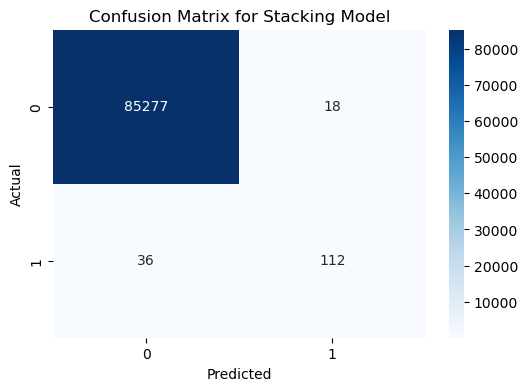

Area Under the Curve (AUC) for Stacking Model: 0.9757186901421617


In [35]:
#Stacking the xgboost and gradient boosting models
from sklearn.ensemble import StackingClassifier
estimators = [
    ('lgbm', model_xgb),
    ('gbc', model_gb)
]
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

# Fit the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_stack = stacking_model.predict(X_test)

# Evaluate the stacking model
print("Classification Report for Stacking Model:\n", classification_report(y_test, y_pred_stack))

# confusion matrix
conf_matrix_stack = confusion_matrix(y_test, y_pred_stack)
conf_matrix_stack

# plotting the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_stack, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Stacking Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# AUC Score
roc_auc_stack = roc_auc_score(y_test, y_prob_stack)
print("Area Under the Curve (AUC) for Stacking Model:", roc_auc_stack)

### **Discussion**

The stacking model produces **TN=85,277**, **FP=18**, **FN=36**, **TP=112**. That gives fraud **precision=0.86** (few false alarms) and **recall=0.76** (misses 36 fraud cases). AUC (~0.98) and AP (~0.83) show strong ranking.

*Conclusion: *it’s **usable**, but it’s **not better than the LightGBM/Gradient Boosting**, which had similar FP (~19) but **fewer missed fraud (FN=29)**.
